In [2]:
pip install opencv-python


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: /Users/jmdhanyakumar/task04/tfenv/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


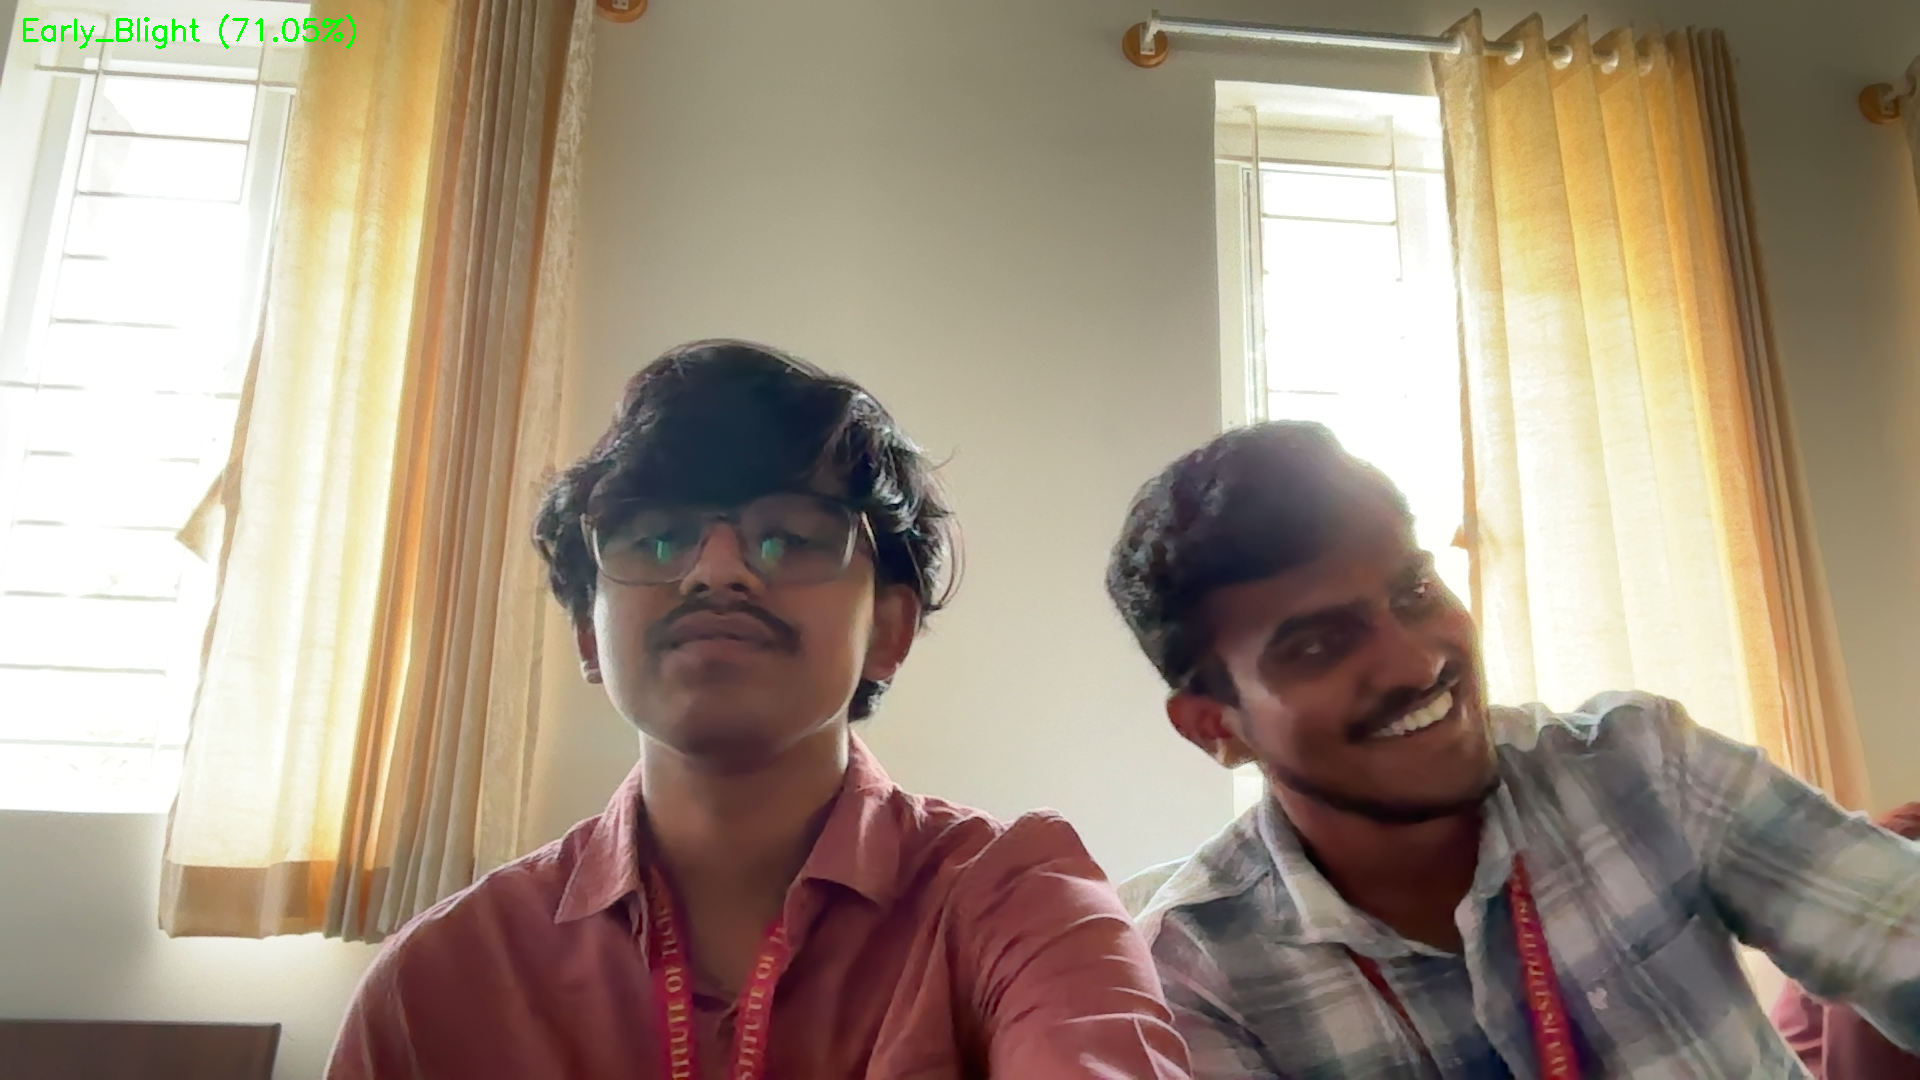

KeyboardInterrupt: 

In [2]:
import cv2
import tensorflow as tf
import numpy as np
from IPython.display import display, clear_output
from PIL import Image

# LOAD MODEL
model = tf.keras.models.load_model(
    "/Users/jmdhanyakumar/Desktop/MPROJECT/models/tomato_disease_model.h5"
)

# CLASS NAMES
class_names = [
    "Bacterial_Spot",
    "Cercospora_leaf_mold",
    "Early_Blight",
    "Healthy",
    "Insect_Damage",
    "Late_Blight",
    "Leaf_Miner",
    "Leaf_Mold",
    "Spider_Mites",
    "Tomato_Leaf_Curl_Virus"
]

# START CAMERA
cap = cv2.VideoCapture(0)

while True:

    ret, frame = cap.read()

    if not ret:
        break

    # RESIZE FOR MODEL
    img = cv2.resize(frame, (224,224))

    # PREPROCESS
    img_array = np.expand_dims(img, axis=0)

    # PREDICT
    prediction = model.predict(img_array, verbose=0)

    predicted_class = class_names[np.argmax(prediction)]

    confidence = np.max(prediction) * 100

    # DISPLAY TEXT
    text = f"{predicted_class} ({confidence:.2f}%)"

    cv2.putText(
        frame,
        text,
        (20,40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0,255,0),
        2
    )

    # CONVERT IMAGE
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    img_pil = Image.fromarray(frame_rgb)

    # SHOW FRAME
    clear_output(wait=True)
    display(img_pil)

    # PRESS CTRL+C IN NOTEBOOK TO STOP

SyntaxError: invalid syntax (3594788736.py, line 1)